# IBM HR Analytics Attrition: Cleaning, EDA & Feature Engineering

## tl;dr
- The dataset has **1,470 employee records and 35 columns**. It contains **0 missing cells, 0 duplicate rows, and 0 duplicate employee IDs**.
- Overall attrition is **16.1%**: 237 employees marked `Yes` and 1,233 marked `No`.
- `OverTime` is the clearest group difference in this EDA: overtime employees attrit at **30.5%**, compared with **10.4%** for non-overtime employees.
- Early-career employees have meaningfully higher attrition: employees with `TotalWorkingYears <= 5` attrit at **28.8%**, compared with **12.7%** for everyone else.
- The highest-risk job-role/travel groups are visible in simple group comparisons: `Sales Representative` has **39.8%** attrition and `Travel_Frequently` has **24.9%** attrition.

## Context & Methods

This notebook uses the IBM HR Analytics Employee Attrition & Performance dataset from Kaggle. The Kaggle file is `WA_Fn-UseC_-HR-Employee-Attrition.csv`; because direct Kaggle downloads often require credentials, this notebook first looks for a local cached copy and then falls back to a public raw CSV mirror of the same file.

### Key Assumptions
- `Attrition` is treated as the target label for future modeling.
- IQR outliers in variables such as income, tenure, and promotion lag are treated as plausible HR observations unless they violate logical domain bounds.
- For modeling hygiene, constant columns and employee identifiers are excluded from the model-ready frame, while original raw fields are preserved.

In [1]:
# If running in a minimal local environment, install these first:
# %pip install pandas numpy matplotlib seaborn

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

DATA_FILE = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
SOURCE_KAGGLE = "https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/data"
MIRROR_URL = "https://raw.githubusercontent.com/mragpavank/ibm-hr-analytics-attrition-dataset/master/WA_Fn-UseC_-HR-Employee-Attrition.csv"

candidate_paths = [
    Path("data") / DATA_FILE,
    Path("..") / "data" / DATA_FILE,
    Path.cwd() / "data" / DATA_FILE,
]

local_path = next((path for path in candidate_paths if path.exists()), None)
if local_path is not None:
    df_raw = pd.read_csv(local_path, encoding="utf-8-sig")
    source_used = str(local_path)
else:
    df_raw = pd.read_csv(MIRROR_URL, encoding="utf-8-sig")
    source_used = MIRROR_URL

df_raw.columns = df_raw.columns.str.replace("﻿", "", regex=False)

print(f"Source used: {source_used}")
print(f"Raw shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]:,} columns")
display(df_raw.head())

Source used: data/WA_Fn-UseC_-HR-Employee-Attrition.csv
Raw shape: 1,470 rows x 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Data

### 1. Audit Missing Values, Duplicates, Constants, and Logical Bounds

In [2]:
missing_by_column = df_raw.isna().sum().sort_values(ascending=False)
duplicate_rows = int(df_raw.duplicated().sum())
duplicate_employee_numbers = int(df_raw["EmployeeNumber"].duplicated().sum())
constant_columns = [col for col in df_raw.columns if df_raw[col].nunique(dropna=False) == 1]

summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "missing_cells",
        "columns_with_missing_values",
        "duplicate_rows",
        "duplicate_employee_numbers",
        "constant_columns",
    ],
    "value": [
        f"{df_raw.shape[0]:,}",
        f"{df_raw.shape[1]:,}",
        f"{int(missing_by_column.sum()):,}",
        f"{int((missing_by_column > 0).sum()):,}",
        f"{duplicate_rows:,}",
        f"{duplicate_employee_numbers:,}",
        ", ".join(constant_columns) if constant_columns else "None",
    ],
})

display(summary)

print("Columns with missing values:")
display(missing_by_column[missing_by_column > 0].to_frame("missing_count"))

,metric,value
0,rows,"1,470"
1,columns,35
2,missing_cells,0
3,columns_with_missing_values,0
4,duplicate_rows,0
5,duplicate_employee_numbers,0
6,constant_columns,"EmployeeCount, Over18, StandardHours"


Columns with missing values:


,missing_count


In [3]:
# Logical validity checks for bounded fields. Rows outside these ranges would be obvious invalid outliers.
logical_bounds = {
    "Age": (18, 65),
    "Education": (1, 5),
    "EnvironmentSatisfaction": (1, 4),
    "JobInvolvement": (1, 4),
    "JobSatisfaction": (1, 4),
    "PerformanceRating": (1, 4),
    "RelationshipSatisfaction": (1, 4),
    "WorkLifeBalance": (1, 4),
    "PercentSalaryHike": (0, 100),
    "StockOptionLevel": (0, 3),
    "TotalWorkingYears": (0, 60),
    "YearsAtCompany": (0, 60),
    "YearsInCurrentRole": (0, 60),
    "YearsSinceLastPromotion": (0, 60),
    "YearsWithCurrManager": (0, 60),
}

bound_violations = []
valid_mask = pd.Series(True, index=df_raw.index)
for column, (lower, upper) in logical_bounds.items():
    if column in df_raw.columns:
        column_valid = df_raw[column].between(lower, upper) | df_raw[column].isna()
        violations = int((~column_valid).sum())
        bound_violations.append({
            "column": column,
            "lower_bound": lower,
            "upper_bound": upper,
            "violating_rows": violations,
        })
        valid_mask &= column_valid

bound_violations = pd.DataFrame(bound_violations).sort_values("violating_rows", ascending=False)
display(bound_violations)
print(f"Rows failing logical bounds: {(~valid_mask).sum():,}")

,column,lower_bound,upper_bound,violating_rows
0,Age,18,65,0
1,Education,1,5,0
2,EnvironmentSatisfaction,1,4,0
3,JobInvolvement,1,4,0
4,JobSatisfaction,1,4,0
5,PerformanceRating,1,4,0
6,RelationshipSatisfaction,1,4,0
7,WorkLifeBalance,1,4,0
8,PercentSalaryHike,0,100,0
9,StockOptionLevel,0,3,0


Rows failing logical bounds: 0


### 2. Apply Cleaning Rules

Cleaning is intentionally conservative because the raw dataset is already tidy. The workflow removes duplicates if present, imputes missing values if present, removes logically invalid rows if present, and keeps a model-ready copy without constant identifier-like columns.

In [4]:
df_clean = df_raw.drop_duplicates().loc[valid_mask].copy()

numeric_columns = df_clean.select_dtypes(include="number").columns.tolist()
categorical_columns = df_clean.select_dtypes(exclude="number").columns.tolist()

# No missing values are present in this dataset. These rules make the notebook robust if the source copy changes.
for column in numeric_columns:
    if df_clean[column].isna().any():
        df_clean[column] = df_clean[column].fillna(df_clean[column].median())

for column in categorical_columns:
    if df_clean[column].isna().any():
        df_clean[column] = df_clean[column].fillna("Unknown")

identifier_columns = ["EmployeeNumber"]
model_exclude_columns = [col for col in constant_columns + identifier_columns if col in df_clean.columns]
df_model_ready = df_clean.drop(columns=model_exclude_columns).copy()

print(f"Cleaned shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]:,} columns")
print(f"Model-ready shape before feature engineering: {df_model_ready.shape[0]:,} rows x {df_model_ready.shape[1]:,} columns")
print(f"Excluded from model-ready frame: {model_exclude_columns}")

Cleaned shape: 1,470 rows x 35 columns
Model-ready shape before feature engineering: 1,470 rows x 31 columns
Excluded from model-ready frame: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']


### 3. Identify and Handle IQR Outliers

The IQR rule highlights skewed but plausible HR values such as high income, long tenure, and long promotion gaps. Rather than deleting these records, the notebook preserves originals and creates capped companion columns for future models that are sensitive to extreme values.

In [5]:
def iqr_outlier_summary(dataframe: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []
    for column in columns:
        q1 = dataframe[column].quantile(0.25)
        q3 = dataframe[column].quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            lower = upper = np.nan
            count = 0
        else:
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            count = int(((dataframe[column] < lower) | (dataframe[column] > upper)).sum())
        rows.append({
            "column": column,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_fence": lower,
            "upper_fence": upper,
            "iqr_outlier_count": count,
            "min": dataframe[column].min(),
            "max": dataframe[column].max(),
        })
    return pd.DataFrame(rows).sort_values("iqr_outlier_count", ascending=False)

numeric_for_outliers = [col for col in numeric_columns if col != "EmployeeNumber"]
outlier_report = iqr_outlier_summary(df_clean, numeric_for_outliers)
display(outlier_report[outlier_report["iqr_outlier_count"] > 0].round(2))

cap_columns = [
    "MonthlyIncome",
    "NumCompaniesWorked",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsSinceLastPromotion",
]

for column in cap_columns:
    q1 = df_clean[column].quantile(0.25)
    q3 = df_clean[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df_model_ready[f"{column}_iqr_capped"] = df_clean[column].clip(lower=lower, upper=upper)

print("Created capped companion columns:")
print([f"{column}_iqr_capped" for column in cap_columns])

,column,q1,q3,iqr,lower_fence,upper_fence,iqr_outlier_count,min,max
19,TrainingTimesLastYear,2.0,3.0,1.0,0.5,4.5,238,0,6
10,MonthlyIncome,2911.0,8379.0,5468.0,-5291.0,16581.0,114,1009,19999
23,YearsSinceLastPromotion,0.0,3.0,3.0,-4.5,7.5,107,0,15
21,YearsAtCompany,3.0,9.0,6.0,-6.0,18.0,104,0,40
17,StockOptionLevel,0.0,1.0,1.0,-1.5,2.5,85,0,3
18,TotalWorkingYears,6.0,15.0,9.0,-7.5,28.5,63,0,40
12,NumCompaniesWorked,1.0,4.0,3.0,-3.5,8.5,52,0,9
22,YearsInCurrentRole,2.0,7.0,5.0,-5.5,14.5,21,0,18
24,YearsWithCurrManager,2.0,7.0,5.0,-5.5,14.5,14,0,17


Created capped companion columns:
['MonthlyIncome_iqr_capped', 'NumCompaniesWorked_iqr_capped', 'TotalWorkingYears_iqr_capped', 'YearsAtCompany_iqr_capped', 'YearsSinceLastPromotion_iqr_capped']


## Results

### 4. Overall Attrition Balance

,Attrition,employees,share,share_pct
0,No,1233,0.838776,83.9
1,Yes,237,0.161224,16.1


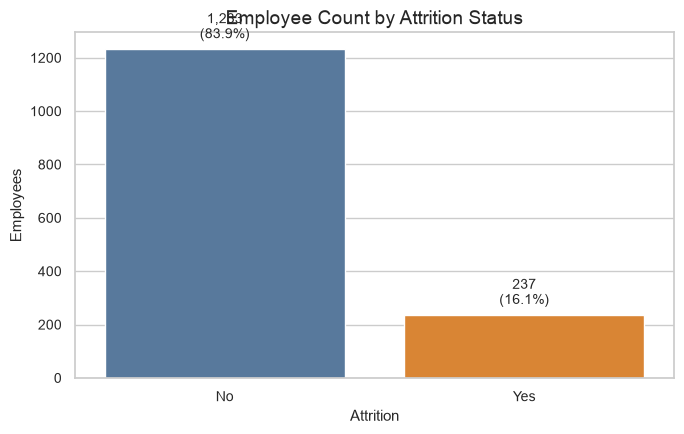

In [6]:
df_clean["AttritionFlag"] = (df_clean["Attrition"] == "Yes").astype(int)
df_model_ready["AttritionFlag"] = df_clean["AttritionFlag"]

attrition_counts = (
    df_clean["Attrition"]
    .value_counts()
    .rename_axis("Attrition")
    .reset_index(name="employees")
)
attrition_counts["share"] = attrition_counts["employees"] / attrition_counts["employees"].sum()

display(attrition_counts.assign(share_pct=(attrition_counts["share"] * 100).round(1)))

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=attrition_counts, x="Attrition", y="employees", palette=["#4C78A8", "#F58518"], ax=ax)
ax.set_title("Employee Count by Attrition Status")
ax.set_xlabel("Attrition")
ax.set_ylabel("Employees")
for patch, (_, row) in zip(ax.patches, attrition_counts.iterrows()):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 25,
        f"{row['employees']:,}\n({row['share']:.1%})",
        ha="center",
        va="bottom",
        fontsize=10,
    )
plt.tight_layout()
plt.savefig("outputs/attrition_count_bar.png", dpi=160, bbox_inches="tight")
plt.show()

### 5. Numeric Distributions by Attrition

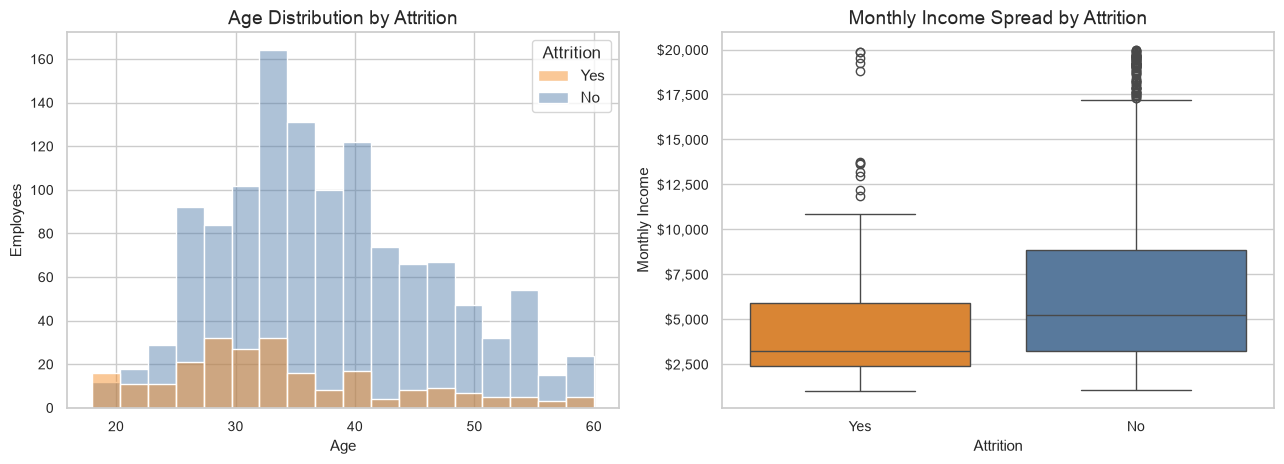

,Age,MonthlyIncome,DistanceFromHome,TotalWorkingYears,YearsAtCompany
Attrition,,,,,
No,37.56,6832.74,8.92,11.86,7.37
Yes,33.61,4787.09,10.63,8.24,5.13


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.histplot(
    data=df_clean,
    x="Age",
    hue="Attrition",
    multiple="layer",
    bins=18,
    alpha=0.45,
    palette={"No": "#4C78A8", "Yes": "#F58518"},
    ax=axes[0],
)
axes[0].set_title("Age Distribution by Attrition")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Employees")

sns.boxplot(
    data=df_clean,
    x="Attrition",
    y="MonthlyIncome",
    palette={"No": "#4C78A8", "Yes": "#F58518"},
    ax=axes[1],
)
axes[1].set_title("Monthly Income Spread by Attrition")
axes[1].set_xlabel("Attrition")
axes[1].set_ylabel("Monthly Income")
axes[1].yaxis.set_major_formatter(lambda value, _: f"${value:,.0f}")

plt.tight_layout()
plt.savefig("outputs/age_income_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

numeric_comparison = df_clean.groupby("Attrition")[[
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "TotalWorkingYears",
    "YearsAtCompany",
]].mean().round(2)
display(numeric_comparison)

### 6. Group Comparisons

,OverTime,employees,attrition_yes,attrition_rate_pct
1,Yes,416,127,30.5
0,No,1054,110,10.4


,BusinessTravel,employees,attrition_yes,attrition_rate_pct
1,Travel_Frequently,277,69,24.9
2,Travel_Rarely,1043,156,15.0
0,Non-Travel,150,12,8.0


,JobRole,employees,attrition_yes,attrition_rate_pct
8,Sales Representative,83,33,39.8
2,Laboratory Technician,259,62,23.9
1,Human Resources,52,12,23.1
7,Sales Executive,326,57,17.5
6,Research Scientist,292,47,16.1
4,Manufacturing Director,145,10,6.9
0,Healthcare Representative,131,9,6.9
3,Manager,102,5,4.9
5,Research Director,80,2,2.5


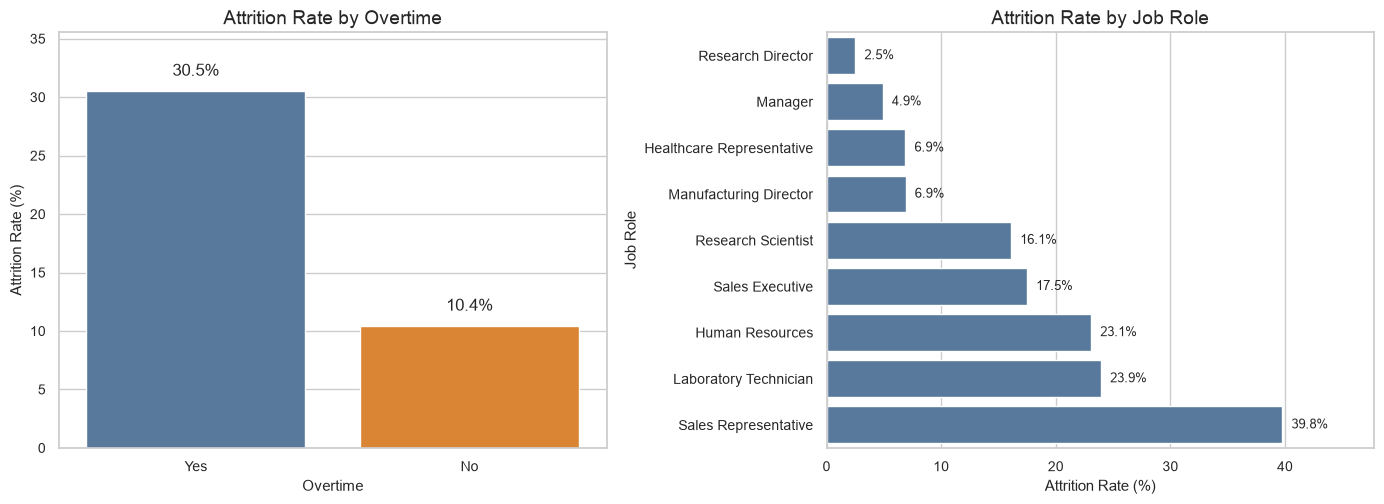

In [8]:
def attrition_rate_table(dataframe: pd.DataFrame, group_col: str) -> pd.DataFrame:
    grouped = (
        dataframe.groupby(group_col)
        .agg(
            employees=("AttritionFlag", "size"),
            attrition_rate=("AttritionFlag", "mean"),
            attrition_yes=("AttritionFlag", "sum"),
        )
        .reset_index()
    )
    grouped["attrition_rate_pct"] = grouped["attrition_rate"] * 100
    return grouped.sort_values("attrition_rate", ascending=False)

overtime_rates = attrition_rate_table(df_clean, "OverTime")
travel_rates = attrition_rate_table(df_clean, "BusinessTravel")
role_rates = attrition_rate_table(df_clean, "JobRole")

display(overtime_rates[["OverTime", "employees", "attrition_yes", "attrition_rate_pct"]].round(1))
display(travel_rates[["BusinessTravel", "employees", "attrition_yes", "attrition_rate_pct"]].round(1))
display(role_rates[["JobRole", "employees", "attrition_yes", "attrition_rate_pct"]].round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

sns.barplot(
    data=overtime_rates,
    x="OverTime",
    y="attrition_rate_pct",
    palette=["#4C78A8", "#F58518"],
    ax=axes[0],
)
axes[0].set_title("Attrition Rate by Overtime")
axes[0].set_xlabel("Overtime")
axes[0].set_ylabel("Attrition Rate (%)")
axes[0].set_ylim(0, max(35, overtime_rates["attrition_rate_pct"].max() + 5))
for patch in axes[0].patches:
    height = patch.get_height()
    axes[0].text(patch.get_x() + patch.get_width() / 2, height + 1, f"{height:.1f}%", ha="center", va="bottom")

role_plot = role_rates.sort_values("attrition_rate_pct", ascending=True)
sns.barplot(
    data=role_plot,
    y="JobRole",
    x="attrition_rate_pct",
    color="#4C78A8",
    ax=axes[1],
)
axes[1].set_title("Attrition Rate by Job Role")
axes[1].set_xlabel("Attrition Rate (%)")
axes[1].set_ylabel("Job Role")
for patch in axes[1].patches:
    width = patch.get_width()
    axes[1].text(width + 0.8, patch.get_y() + patch.get_height() / 2, f"{width:.1f}%", va="center", fontsize=9)
axes[1].set_xlim(0, role_rates["attrition_rate_pct"].max() + 8)

plt.tight_layout()
plt.savefig("outputs/group_attrition_rates.png", dpi=160, bbox_inches="tight")
plt.show()

### 7. Correlation Heatmap

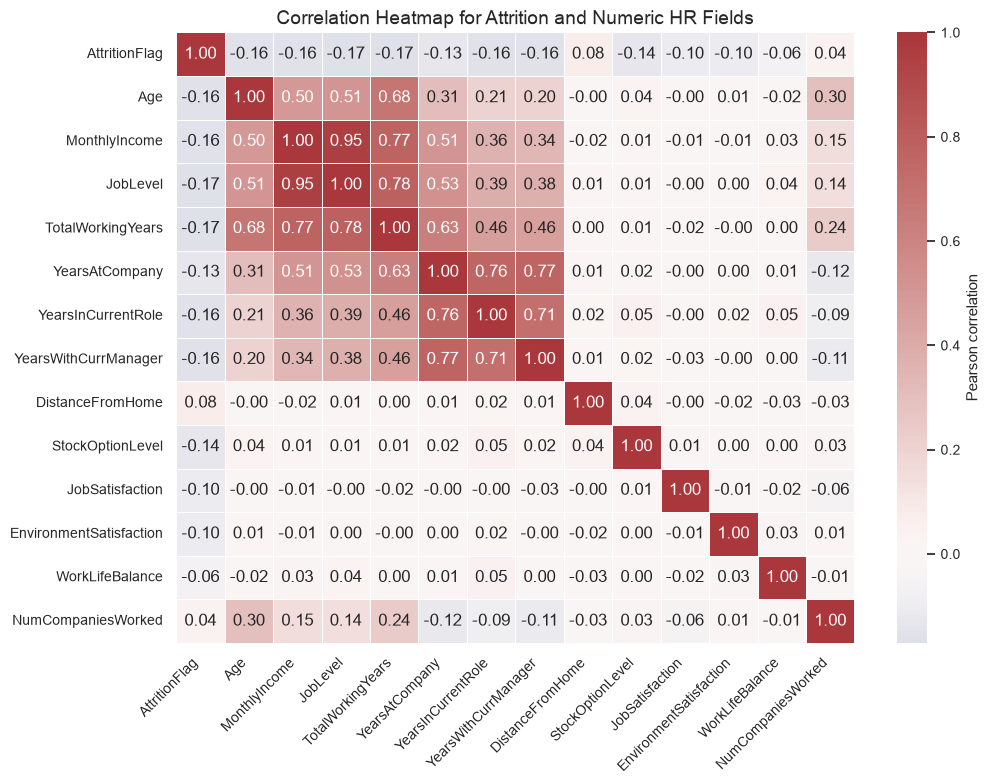

,corr_with_attrition
TotalWorkingYears,-0.171
JobLevel,-0.169
YearsInCurrentRole,-0.161
MonthlyIncome,-0.160
Age,-0.159
YearsWithCurrManager,-0.156
StockOptionLevel,-0.137
YearsAtCompany,-0.134
JobSatisfaction,-0.103
EnvironmentSatisfaction,-0.103


In [9]:
correlation_columns = [
    "AttritionFlag",
    "Age",
    "MonthlyIncome",
    "JobLevel",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsWithCurrManager",
    "DistanceFromHome",
    "StockOptionLevel",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "WorkLifeBalance",
    "NumCompaniesWorked",
]

corr = df_clean[correlation_columns].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10.5, 8))
sns.heatmap(
    corr,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    cbar_kws={"label": "Pearson correlation"},
    ax=ax,
)
ax.set_title("Correlation Heatmap for Attrition and Numeric HR Fields")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

attrition_corr = corr["AttritionFlag"].drop("AttritionFlag").sort_values(key=lambda x: x.abs(), ascending=False)
display(attrition_corr.to_frame("corr_with_attrition").round(3))

## Feature Engineering

The following engineered features are intended for future modeling. They are simple, interpretable, and derived from existing columns without using future information.

In [10]:
# Target encoding for supervised modeling.
df_model_ready["AttritionFlag"] = (df_model_ready["Attrition"] == "Yes").astype(int)

# Tenure and growth context.
df_model_ready["TenureRatio"] = (
    df_clean["YearsAtCompany"] / df_clean["TotalWorkingYears"].replace(0, np.nan)
).fillna(0)
df_model_ready["IncomePerYearWorked"] = (
    df_clean["MonthlyIncome"] / df_clean["TotalWorkingYears"].replace(0, np.nan)
).fillna(df_clean["MonthlyIncome"])
df_model_ready["PromotionLagRatio"] = (
    df_clean["YearsSinceLastPromotion"] / df_clean["YearsAtCompany"].replace(0, np.nan)
).fillna(0)

# Interpretable risk flags.
df_model_ready["IsEarlyCareer"] = (df_clean["TotalWorkingYears"] <= 5).astype(int)
df_model_ready["LongCommute"] = (df_clean["DistanceFromHome"] >= 10).astype(int)
df_model_ready["LowSatisfaction"] = (
    (df_clean["EnvironmentSatisfaction"] <= 2)
    | (df_clean["JobSatisfaction"] <= 2)
    | (df_clean["RelationshipSatisfaction"] <= 2)
).astype(int)
df_model_ready["WorkIntensityRisk"] = (
    (df_clean["OverTime"] == "Yes").astype(int)
    + (df_clean["BusinessTravel"] == "Travel_Frequently").astype(int)
    + df_model_ready["LongCommute"]
)

engineered_features = [
    "TenureRatio",
    "IncomePerYearWorked",
    "PromotionLagRatio",
    "IsEarlyCareer",
    "LongCommute",
    "LowSatisfaction",
    "WorkIntensityRisk",
]

feature_summary = df_model_ready[engineered_features + ["AttritionFlag"]].agg(["mean", "median", "min", "max"]).T.round(3)
display(feature_summary)

display(df_model_ready[engineered_features + ["Attrition", "AttritionFlag"]].head())

,mean,median,min,max
TenureRatio,0.678,0.800,0.00,1.0
IncomePerYearWorked,718.266,602.815,100.05,2994.0
PromotionLagRatio,0.290,0.167,0.00,1.0
IsEarlyCareer,0.215,0.000,0.00,1.0
LongCommute,0.361,0.000,0.00,1.0
LowSatisfaction,0.773,1.000,0.00,1.0
WorkIntensityRisk,0.832,1.000,0.00,3.0
AttritionFlag,0.161,0.000,0.00,1.0


,TenureRatio,IncomePerYearWorked,PromotionLagRatio,IsEarlyCareer,LongCommute,LowSatisfaction,WorkIntensityRisk,Attrition,AttritionFlag
0,0.750000,749.125000,0.000,0,0,1,1,Yes,1
1,1.000000,513.000000,0.100,0,0,1,1,No,0
2,0.000000,298.571429,0.000,0,0,1,1,Yes,1
3,1.000000,363.625000,0.375,0,0,0,2,No,0
4,0.333333,578.000000,1.000,0,0,1,0,No,0


,feature,value,employees,attrition_rate_pct
0,IsEarlyCareer,0,1154,12.7
1,IsEarlyCareer,1,316,28.8
2,LongCommute,0,940,14.1
3,LongCommute,1,530,19.6
4,LowSatisfaction,0,333,12.6
5,LowSatisfaction,1,1137,17.2
6,WorkIntensityRisk,0,569,7.9
7,WorkIntensityRisk,1,611,16.2
8,WorkIntensityRisk,2,258,30.2
9,WorkIntensityRisk,3,32,46.9


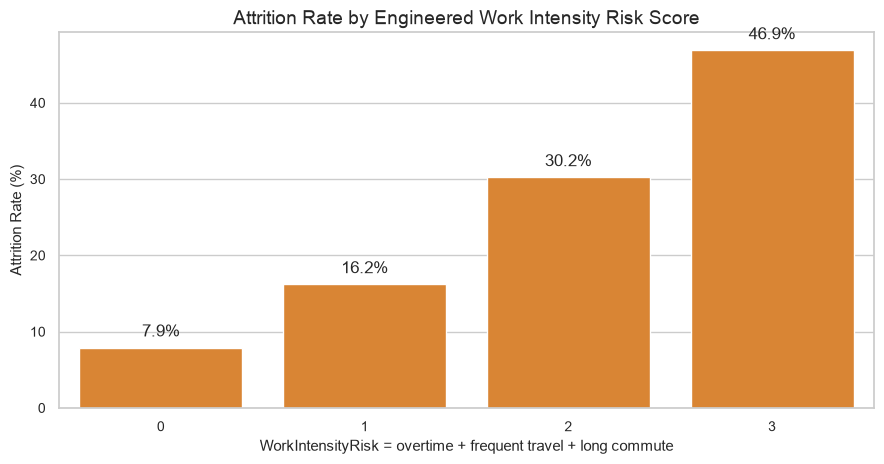

In [11]:
feature_rate_checks = []
for feature in ["IsEarlyCareer", "LongCommute", "LowSatisfaction", "WorkIntensityRisk"]:
    grouped = (
        df_model_ready.groupby(feature)["AttritionFlag"]
        .agg(employees="size", attrition_rate="mean")
        .reset_index()
    )
    grouped["feature"] = feature
    grouped["attrition_rate_pct"] = grouped["attrition_rate"] * 100
    feature_rate_checks.append(grouped[["feature", feature, "employees", "attrition_rate_pct"]].rename(columns={feature: "value"}))

feature_rate_checks = pd.concat(feature_rate_checks, ignore_index=True)
display(feature_rate_checks.round(1))

fig, ax = plt.subplots(figsize=(9, 4.8))
risk_plot = attrition_rate_table(df_model_ready, "WorkIntensityRisk").sort_values("WorkIntensityRisk")
sns.barplot(data=risk_plot, x="WorkIntensityRisk", y="attrition_rate_pct", color="#F58518", ax=ax)
ax.set_title("Attrition Rate by Engineered Work Intensity Risk Score")
ax.set_xlabel("WorkIntensityRisk = overtime + frequent travel + long commute")
ax.set_ylabel("Attrition Rate (%)")
for patch in ax.patches:
    height = patch.get_height()
    ax.text(patch.get_x() + patch.get_width() / 2, height + 1, f"{height:.1f}%", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("outputs/work_intensity_risk_attrition.png", dpi=160, bbox_inches="tight")
plt.show()

## Takeaways

1. **The dataset is already clean at the row/cell level.** There are no missing cells, duplicate rows, or duplicate employee IDs. The main cleanup choice is to exclude constant fields (`EmployeeCount`, `Over18`, `StandardHours`) and the identifier (`EmployeeNumber`) from future modeling.
2. **Attrition is imbalanced but not rare.** `Yes` accounts for **16.1%** of employees, so future modeling should evaluate class-aware metrics such as recall, precision, ROC-AUC, and PR-AUC rather than accuracy alone.
3. **Overtime is the strongest simple segment signal.** Employees with `OverTime = Yes` have **30.5%** attrition versus **10.4%** for `OverTime = No`.
4. **Career stage and role context matter.** Employees with `TotalWorkingYears <= 5` have **28.8%** attrition, and `Sales Representative` is the highest attrition job role at **39.8%**.
5. **The engineered features add interpretable modeling signal.** `IsEarlyCareer`, `LongCommute`, `LowSatisfaction`, `TenureRatio`, `IncomePerYearWorked`, `PromotionLagRatio`, and `WorkIntensityRisk` translate raw HR fields into compact tenure, compensation, satisfaction, and workload indicators that a future model can use.